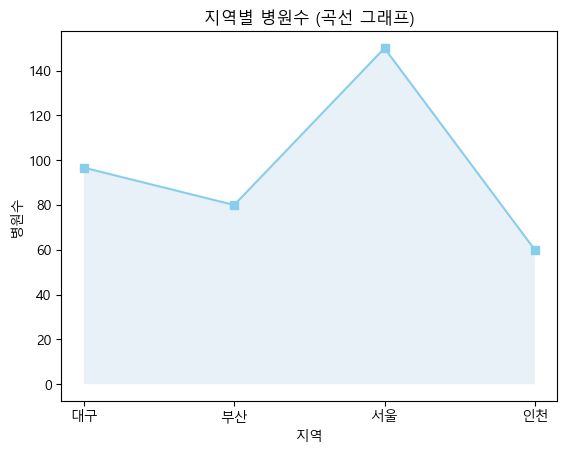

In [11]:
# 반드시 pandas는 import하여 사용한다.
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용한다.
import matplotlib.pyplot as plt

# 숫자 계산 쉽게하는 라이브러리 블러오기
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수 가져오기
from scipy.interpolate import make_interp_spline


# 데이터 생성하기
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    "총인구":[1000000,300000,200000]
})
df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    "병원수":[150,80,60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하면 df1과 df2 합집합이 된다.
merged = pd.merge(df1, df2, on="지역",how="outer")
#merged

# 결측치 처리를 진행한다.
# 결측치는 병원수와, 총인구의 평균으로 정의한다.
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged


# --------------------------------------
# 반드시 한글 깨짐 현상 코드를 삽입한다.
#----------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 꺽은선 그래프
plt.plot(merged['지역'],merged['병원수'],marker='s', color='skyblue')

# 꺽은선 영역 그래프
# fill_between(x,y) => x축 기준으로 선아래를 채움
# plt.fill_between(x,y,alpha=0.3) => 투명도 0.1:거의 투명, 0.3:적당, 1~ : 아주 진함
plt.fill_between(merged['지역'],merged['병원수'],alpha=0.1)

# x를 숫자로 변환하기
x = np.arange(len(merged['지역']))
y = merged['병원수']
smooth = np.linspace(x.min(),x.max(),300)
smooth02 = make_interp_spline(x,y)(smooth)
# 곡선 그래프
# plt.plot(smooth, smooth02)

plt.title('지역별 병원수 (곡선 그래프)')
plt.xlabel('지역')
plt.ylabel('병원수')

plt.show()

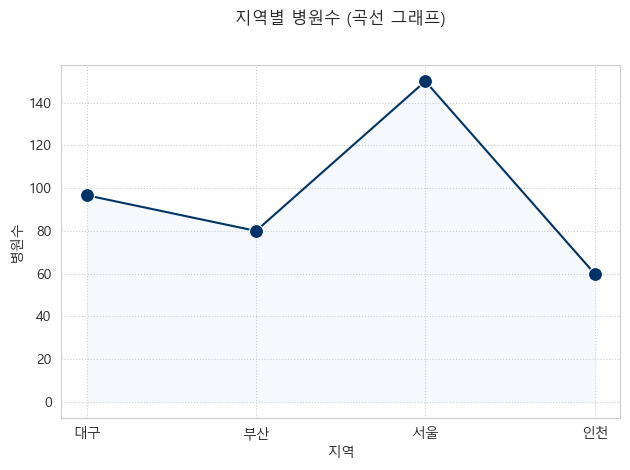

In [7]:
# 반드시 pandas는 import하여 사용한다.
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용한다.
import matplotlib.pyplot as plt
import seaborn as sns

# 숫자 계산 쉽게하는 라이브러리 블러오기
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수 가져오기
from scipy.interpolate import make_interp_spline


# 데이터 생성하기
df1 = pd.DataFrame({
    "지역":["서울","부산","대구"],
    "총인구":[1000000,300000,200000]
})
df2 = pd.DataFrame({
    "지역":["서울","부산","인천"],
    "병원수":[150,80,60]
})

# 데이터 전처리를 위해 merge(병합)을 진행한다.
# outer로 병합하면 df1과 df2 합집합이 된다.
merged = pd.merge(df1, df2, on="지역",how="outer")
#merged

# 결측치 처리를 진행한다.
# 결측치는 병원수와, 총인구의 평균으로 정의한다.
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged

# seaborn 스타일 지정
sns.set_style('whitegrid') # 배경 스타일 설정, dark : 그리드 없이 어두운 배경 지정
sns.set_palette('pastel') # 색상 스타일 지정, deep :진하게

# --------------------------------------
# 반드시 한글 깨짐 현상 코드를 삽입한다.
#----------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 꺽은선 그래프
# plt.plot(merged['지역'],merged['병원수'],marker='s', color='skyblue')
ax = sns.lineplot(x='지역',y='병원수',data=merged, marker='o',markersize=10,color='#003366')

# 꺽은선 영역 그래프
# fill_between(x,y) => x축 기준으로 선아래를 채움
# plt.fill_between(x,y,alpha=0.3) => 투명도 0.1:거의 투명, 0.3:적당, 1~ : 아주 진함
plt.fill_between(merged['지역'],merged['병원수'],alpha=0.1)

# x를 숫자로 변환하기
x = np.arange(len(merged['지역']))
y = merged['병원수']
smooth = np.linspace(x.min(),x.max(),300)
smooth02 = make_interp_spline(x,y)(smooth)
# 곡선 그래프
# plt.plot(smooth, smooth02)

plt.grid(linestyle=':')

plt.title('지역별 병원수 (곡선 그래프)',pad=30)
plt.xlabel('지역')
plt.ylabel('병원수')
plt.tight_layout()
plt.show()